# Chapter Summary

Outlier detection is an important machine learning task used to identify unusual observations that differ significantly from the majority of data points.

Outliers may indicate fraud, sensor failures, network intrusions, manufacturing defects, or rare events. Detecting these observations can improve model quality and provide valuable business insights.

This chapter introduces several anomaly detection techniques including Isolation Forest, One-Class SVM, and Local Outlier Factor (LOF), along with methods for evaluating and handling detected outliers.

# Learning Objectives

After completing this chapter, students should be able to:

- Understand anomaly detection concepts.
- Differentiate novelty detection and outlier detection.
- Apply Isolation Forest.
- Apply One-Class SVM.
- Apply Local Outlier Factor (LOF).
- Evaluate anomaly detection models.
- Handle detected outliers appropriately.

## Introduction to Outlier and Novelty Detection

Outliers are observations that differ significantly from the majority of data.

Novelty detection focuses on identifying new observations that differ from previously observed patterns.

Applications include:

- Fraud detection
- Intrusion detection
- Manufacturing quality control
- Medical diagnosis
- Financial monitoring

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

normal_data = 0.3 * np.random.randn(100, 2)

outliers = np.random.uniform(
    low=-4,
    high=4,
    size=(10, 2)
)

X = np.vstack([
    normal_data,
    outliers
])

print(X.shape)

(110, 2)


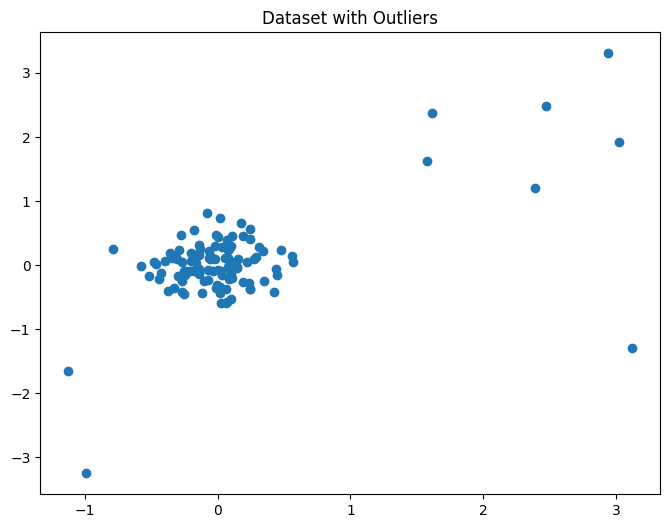

In [2]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.title("Dataset with Outliers")

plt.show()

## Understanding Isolation Forest

Isolation Forest is one of the most popular anomaly detection algorithms.

The main idea is that anomalies are easier to isolate than normal observations.

Advantages:

- Fast execution.
- Scales well to large datasets.
- Effective for high-dimensional data.

In [3]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.1,
    random_state=42
)

predictions = iso_forest.fit_predict(X)

print(predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


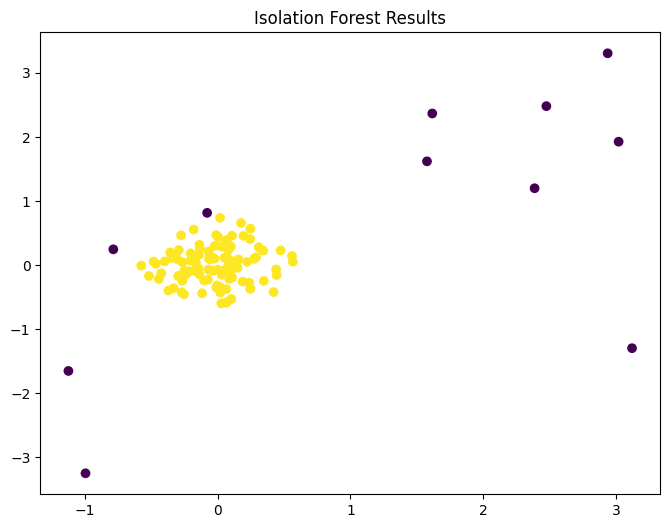

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=predictions
)

plt.title("Isolation Forest Results")

plt.show()

Isolation Forest assigns anomaly labels based on how easily observations can be isolated from the rest of the dataset.

Normal observations receive label 1, while anomalies receive label -1.

## One-Class SVM for Novelty Detection

One-Class SVM learns the boundary of normal observations and identifies data points that fall outside that boundary.

This approach is commonly used for novelty detection.

In [5]:
from sklearn.svm import OneClassSVM

svm_model = OneClassSVM(
    kernel="rbf",
    gamma="auto"
)

svm_predictions = svm_model.fit_predict(X)

print(svm_predictions[:20])

[ 1 -1  1 -1  1  1 -1 -1  1 -1 -1 -1  1  1  1 -1  1 -1 -1 -1]


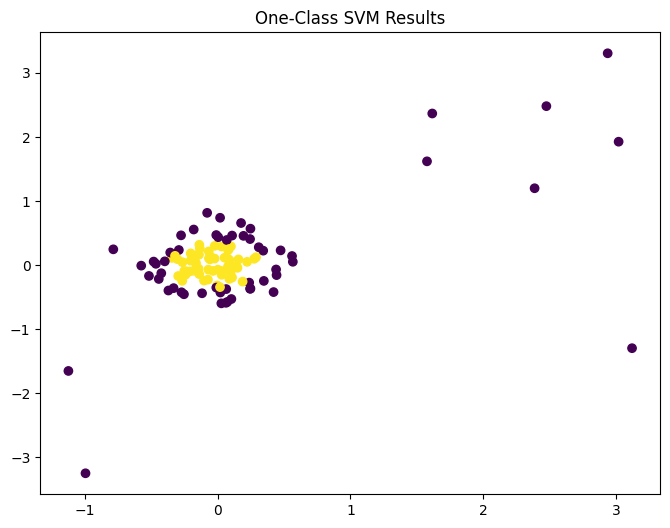

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=svm_predictions
)

plt.title("One-Class SVM Results")

plt.show()

One-Class SVM attempts to learn the distribution of normal observations and classify unusual observations as anomalies.

## Detecting Outliers with Local Outlier Factor (LOF)

LOF identifies anomalies by comparing local densities.

Observations located in regions with significantly lower density than neighboring observations are considered outliers.

In [7]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1
)

lof_predictions = lof.fit_predict(X)

print(lof_predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


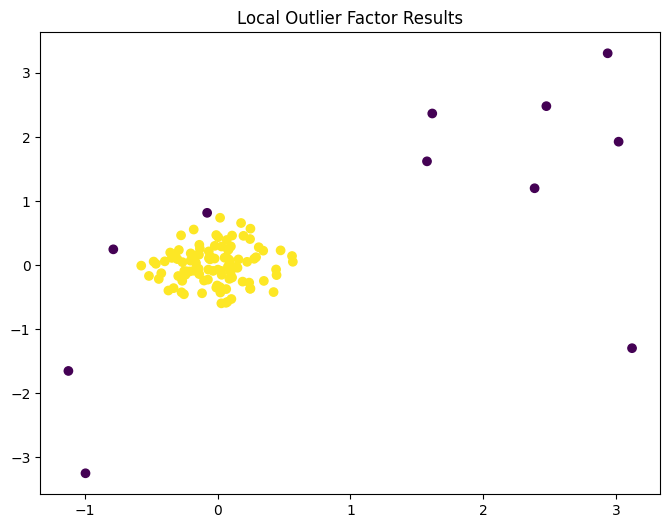

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=lof_predictions
)

plt.title("Local Outlier Factor Results")

plt.show()

LOF evaluates local neighborhood density and identifies observations that appear isolated relative to surrounding points.

## Evaluating Outlier Detection Models

Evaluating anomaly detection models can be difficult because labeled anomalies are often unavailable.

Common evaluation approaches include:

- Precision
- Recall
- F1 Score
- Visual inspection
- Domain expertise

When labels exist, standard classification metrics can be applied.

In [9]:
from sklearn.metrics import classification_report

true_labels = np.ones(len(X))
true_labels[-10:] = -1

print(
    classification_report(
        true_labels,
        predictions
    )
)

              precision    recall  f1-score   support

        -1.0       0.82      0.90      0.86        10
         1.0       0.99      0.98      0.98       100

    accuracy                           0.97       110
   macro avg       0.90      0.94      0.92       110
weighted avg       0.97      0.97      0.97       110



## Handling Detected Outliers

Once anomalies are detected, several actions may be taken:

- Remove observations.
- Correct data errors.
- Investigate unusual behavior.
- Create specialized anomaly models.

The appropriate action depends on the business context and application.

In [10]:
clean_data = X[
    predictions == 1
]

print(
    "Original Shape:",
    X.shape
)

print(
    "Clean Shape:",
    clean_data.shape
)

Original Shape: (110, 2)
Clean Shape: (99, 2)


## Choosing the Right Detection Technique

Use Isolation Forest when:

- Large datasets are available.
- High-dimensional features exist.

Use One-Class SVM when:

- Novelty detection is required.
- Training data mostly contains normal observations.

Use LOF when:

- Local density differences are important.
- Dataset size is moderate.

In [11]:
exercise_iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

exercise_iso.fit_predict(X)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
       -1,  1, -1,  1,  1, -1, -1, -1])

In [12]:
exercise_lof = LocalOutlierFactor(
    contamination=0.05
)

exercise_lof.fit_predict(X)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1, -1, -1,  1,  1, -1, -1, -1])

In [13]:
exercise_svm = OneClassSVM(
    gamma="auto"
)

exercise_svm.fit_predict(X)

array([ 1, -1,  1, -1,  1,  1, -1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1,
       -1, -1, -1,  1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,
        1, -1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,
        1,  1, -1,  1, -1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1, -1,
        1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1, -1,  1,
        1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1, -1,
       -1, -1, -1,  1, -1, -1, -1, -1], dtype=int64)

# Discussion

This chapter introduced several anomaly detection techniques available in scikit-learn.

Isolation Forest, One-Class SVM, and Local Outlier Factor were used to identify unusual observations within a dataset. Each method applies a different strategy for detecting anomalies and may perform differently depending on dataset characteristics.

The experiments demonstrated the importance of anomaly detection for maintaining data quality and identifying unusual events.

# Conclusion

Outlier and novelty detection are essential components of many machine learning applications.

This chapter explored Isolation Forest, One-Class SVM, Local Outlier Factor, evaluation methods, and techniques for handling detected anomalies.

Understanding these methods enables practitioners to identify unusual patterns, improve data quality, and build more reliable machine learning systems.